# Crop Yield Prediction — Regression Track

**Course:** 23CSE301 Machine Learning  
**Review:** Review 1 — Regression Track

This notebook implements the complete regression pipeline:
- Dataset loading and audit
- Feature engineering
- Train-test split
- Preprocessing
- 10 required regression algorithms
- Comparative evaluation using R², RMSE and MAE
- Hyperparameter tuning using GridSearchCV
- 5-fold cross-validation for the two best-performing models
- Predicted-vs-actual plot
- Residual plot
- Tree-based feature importance


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.preprocessing import OneHotEncoder, StandardScaler, PolynomialFeatures
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import (
    LinearRegression,
    Ridge,
    Lasso,
    ElasticNet
)

from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import (
    RandomForestRegressor,
    GradientBoostingRegressor
)

from sklearn.svm import SVR
from sklearn.neighbors import KNeighborsRegressor

from sklearn.metrics import (
    r2_score,
    mean_squared_error,
    mean_absolute_error
)

import warnings
warnings.filterwarnings("ignore")

RANDOM_STATE = 42


## 1. Load Dataset

In [2]:
df = pd.read_csv("crop_yield.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (19689, 9)


,crop,year,season,state,area,production,fertilizer,pesticide,yield
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909


## 2. Basic Dataset Audit

Check the data types, missing values and duplicate records before modelling.

In [3]:
print("Data types:")
print(df.dtypes)

print("\nMissing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nTarget summary:")
print(df["yield"].describe())


Data types:
crop              str
year            int64
season            str
state             str
area          float64
production      int64
fertilizer    float64
pesticide     float64
yield         float64
dtype: object

Missing values:
crop          0
year          0
season        0
state         0
area          0
production    0
fertilizer    0
pesticide     0
yield         0
dtype: int64

Duplicate rows: 0

Target summary:
count    19689.000000
mean        79.954009
std        878.306193
min          0.000000
25%          0.600000
50%          1.030000
75%          2.388889
max      21105.000000
Name: yield, dtype: float64


## 3. Exploratory Data Analysis (EDA)

Exploratory Data Analysis is performed to understand the patterns, distributions, and relationships present in the dataset before applying machine learning models.

The analysis includes:
- Distribution of numerical features
- Distribution of the target variable (`yield`)
- Correlation analysis using a heatmap
- Feature-target relationships using scatter plots
- Identification of skewness and unusual values

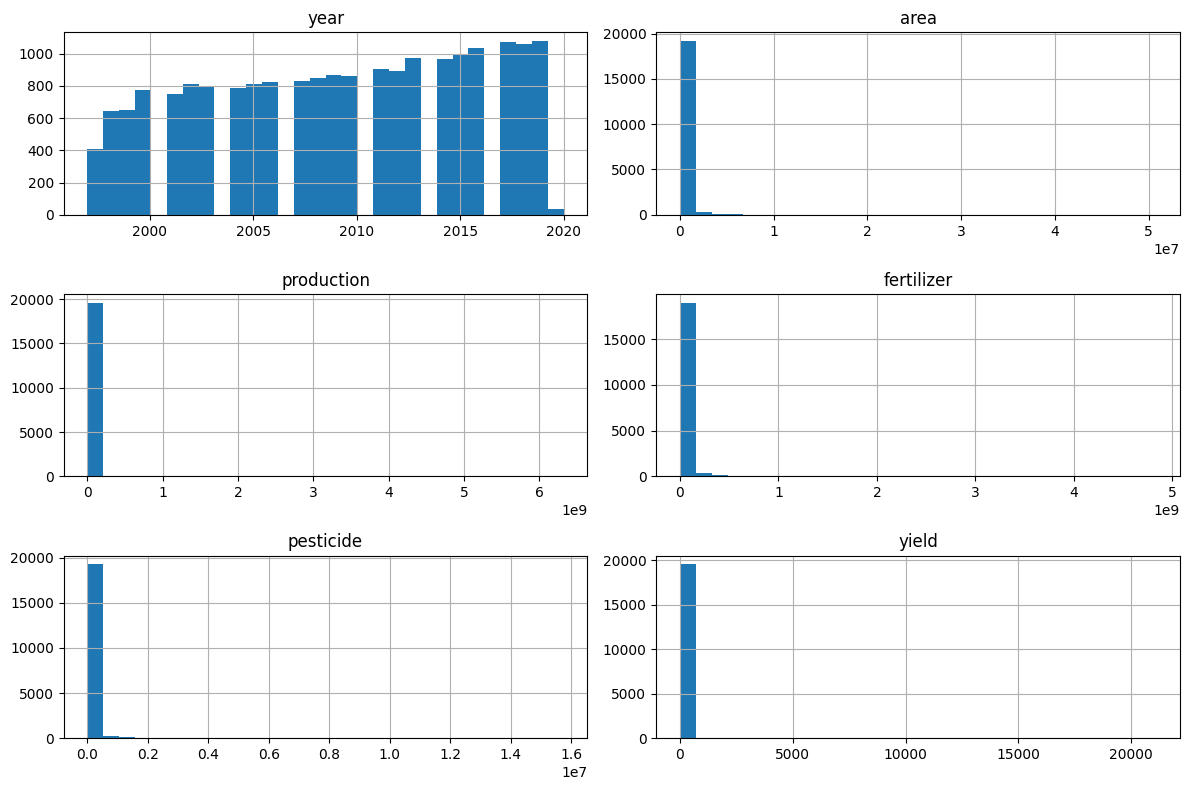

In [5]:
# Select numerical features for distribution analysis
numerical_cols = [
    "year",
    "area",
    "production",
    "fertilizer",
    "pesticide",
    "yield"
]

# Plot the distribution of each numerical feature
df[numerical_cols].hist(figsize=(12, 8), bins=30)

plt.tight_layout()
plt.show()

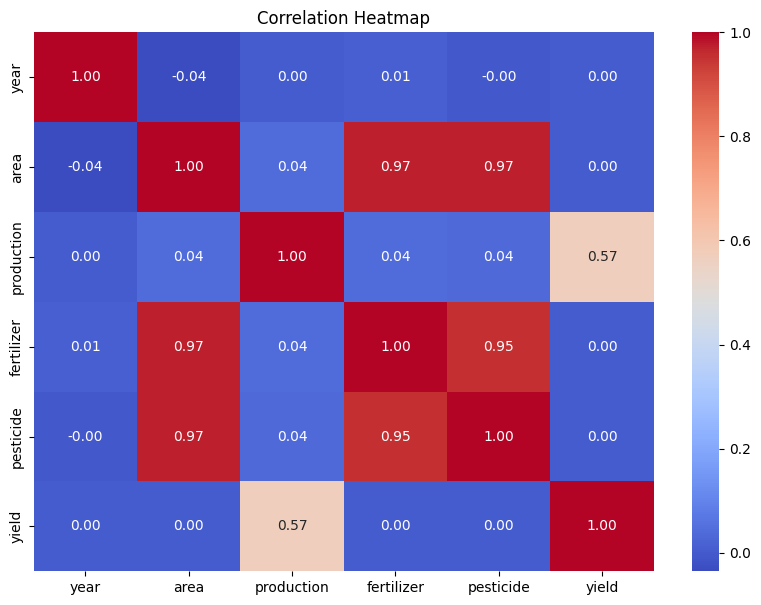

In [6]:
# Calculate correlations between numerical features
corr = df[numerical_cols].corr()

# Visualize the correlation matrix
plt.figure(figsize=(10, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm")

plt.title("Correlation Heatmap")
plt.show()

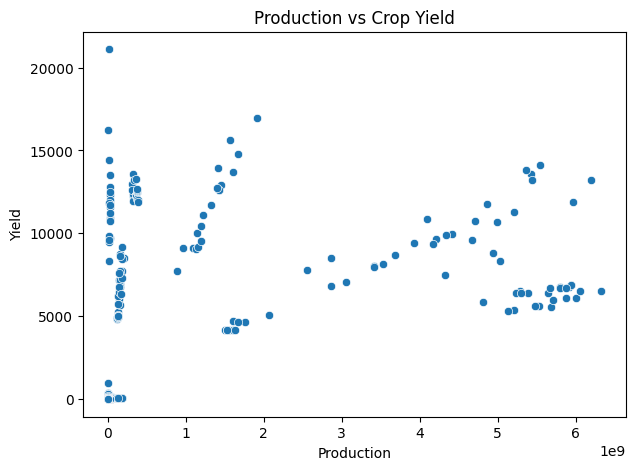

In [7]:
# Analyze the relationship between production and yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="production", y="yield")

plt.title("Production vs Crop Yield")
plt.xlabel("Production")
plt.ylabel("Yield")
plt.show()

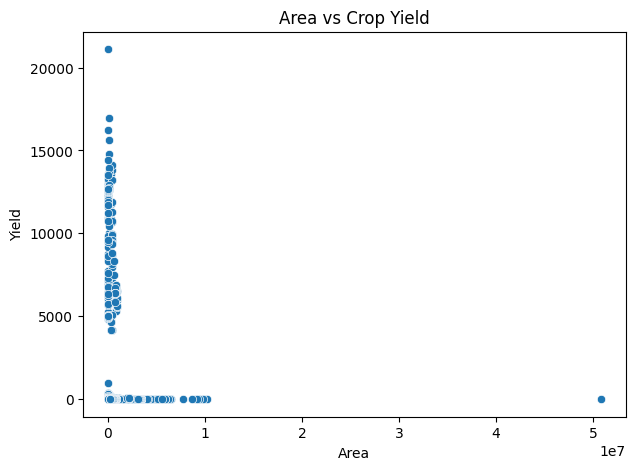

In [8]:
# Analyze the relationship between cultivated area and yield
plt.figure(figsize=(7, 5))
sns.scatterplot(data=df, x="area", y="yield")

plt.title("Area vs Crop Yield")
plt.xlabel("Area")
plt.ylabel("Yield")
plt.show()

## Feature Engineering

Three domain-based features are created:

- **production_per_area** — production normalized by cultivated area.
- **fertilizer_per_area** — fertilizer usage normalized by cultivated area.
- **pesticide_per_area** — pesticide usage normalized by cultivated area.

These features represent productivity and input intensity on an area-normalized basis.

In [4]:
# Avoid division by zero
area_safe = df["area"].replace(0, np.nan)

df["production_per_area"] = df["production"] / area_safe
df["fertilizer_per_area"] = df["fertilizer"] / area_safe
df["pesticide_per_area"] = df["pesticide"] / area_safe

# Remove rows with invalid engineered values
df = df.dropna().reset_index(drop=True)

print("Dataset shape after feature engineering:", df.shape)
df.head()


Dataset shape after feature engineering: (19689, 12)


,crop,year,season,state,area,production,fertilizer,pesticide,yield,production_per_area,fertilizer_per_area,pesticide_per_area
0,Arecanut,1997,Whole Year,Assam,73814.0,56708,7024878.38,22882.34,0.796087,0.768255,95.17,0.31
1,Arhar/Tur,1997,Kharif,Assam,6637.0,4685,631643.29,2057.47,0.710435,0.705891,95.17,0.31
2,Castor seed,1997,Kharif,Assam,796.0,22,75755.32,246.76,0.238333,0.027638,95.17,0.31
3,Coconut,1997,Whole Year,Assam,19656.0,126905000,1870661.52,6093.36,5238.051739,6456.298331,95.17,0.31
4,Cotton(lint),1997,Kharif,Assam,1739.0,794,165500.63,539.09,0.420909,0.456584,95.17,0.31


## 4. Define Features and Target

In [ ]:
X = df.drop("yield", axis=1)
y = df["yield"]

print("Features:")
print(X.columns.tolist())

print("\nTarget:", y.name)


## 5. Train-Test Split

The same 80:20 split is used for every regression algorithm so that model comparisons are fair.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE
)

print("Training set:", X_train.shape)
print("Testing set:", X_test.shape)


## 6. Preprocessing

Categorical variables are one-hot encoded and numerical variables are standardized.

The preprocessing is placed inside a pipeline so that transformations are fitted only on the training data, preventing data leakage.

In [ ]:
categorical_features = [
    "crop",
    "season",
    "state"
]

numerical_features = [
    "year",
    "area",
    "production",
    "fertilizer",
    "pesticide",
    "production_per_area",
    "fertilizer_per_area",
    "pesticide_per_area"
]

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), categorical_features)
    ]
)


## 7. Define the 10 Required Regression Algorithms

In [ ]:
models = {
    "Linear Regression": LinearRegression(),

    "Ridge Regression": Ridge(alpha=1.0),

    "Lasso Regression": Lasso(
        alpha=0.001,
        max_iter=10000
    ),

    "ElasticNet Regression": ElasticNet(
        alpha=0.001,
        l1_ratio=0.5,
        max_iter=10000
    ),

    "Polynomial Regression": Pipeline([
        ("poly", PolynomialFeatures(
            degree=2,
            include_bias=False
        )),
        ("linear", LinearRegression())
    ]),

    "Decision Tree": DecisionTreeRegressor(
        random_state=RANDOM_STATE
    ),

    "Random Forest": RandomForestRegressor(
        n_estimators=100,
        random_state=RANDOM_STATE,
        n_jobs=-1
    ),

    "Gradient Boosting": GradientBoostingRegressor(
        random_state=RANDOM_STATE
    ),

    "SVR": SVR(
        kernel="rbf",
        C=100
    ),

    "KNN": KNeighborsRegressor(
        n_neighbors=5
    )
}


## 8. Train and Evaluate All 10 Models

All models use the same training data, preprocessing pipeline and held-out test set.

In [ ]:
results = []
trained_models = {}

for name, model in models.items():

    pipeline = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipeline.fit(X_train, y_train)

    y_pred = pipeline.predict(X_test)

    results.append({
        "Model": name,
        "R2": r2_score(y_test, y_pred),
        "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
        "MAE": mean_absolute_error(y_test, y_pred)
    })

    trained_models[name] = pipeline

results_df = pd.DataFrame(results)

results_df = results_df.sort_values(
    by="R2",
    ascending=False
).reset_index(drop=True)

results_df.round(4)


## 9. Hyperparameter Tuning

GridSearchCV is applied to at least two regression models as required for Review 1.

Here, **Lasso Regression** and **Random Forest Regression** are tuned.

### 9.1 Lasso Regression — GridSearchCV

In [ ]:
lasso_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", Lasso(max_iter=20000))
])

lasso_params = {
    "model__alpha": [
        0.0001,
        0.001,
        0.01,
        0.1,
        1.0
    ]
}

lasso_grid = GridSearchCV(
    lasso_pipeline,
    lasso_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

lasso_grid.fit(X_train, y_train)

print("Best Lasso parameters:")
print(lasso_grid.best_params_)

print("\nBest Lasso CV R2:")
print(lasso_grid.best_score_)


In [ ]:
lasso_pred = lasso_grid.predict(X_test)

lasso_tuned_result = {
    "Model": "Tuned Lasso",
    "R2": r2_score(y_test, lasso_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, lasso_pred)),
    "MAE": mean_absolute_error(y_test, lasso_pred)
}

pd.DataFrame([lasso_tuned_result]).round(4)


### 9.2 Random Forest Regression — GridSearchCV

In [ ]:
rf_pipeline = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestRegressor(
        random_state=RANDOM_STATE,
        n_jobs=-1
    ))
])

rf_params = {
    "model__n_estimators": [100, 200],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5]
}

rf_grid = GridSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

rf_grid.fit(X_train, y_train)

print("Best Random Forest parameters:")
print(rf_grid.best_params_)

print("\nBest Random Forest CV R2:")
print(rf_grid.best_score_)


In [ ]:
rf_pred = rf_grid.predict(X_test)

rf_tuned_result = {
    "Model": "Tuned Random Forest",
    "R2": r2_score(y_test, rf_pred),
    "RMSE": np.sqrt(mean_squared_error(y_test, rf_pred)),
    "MAE": mean_absolute_error(y_test, rf_pred)
}

pd.DataFrame([rf_tuned_result]).round(4)


## 10. Tuning Improvement

Compare the original and tuned versions of the two tuned models.

In [ ]:
original_lasso = results_df[
    results_df["Model"] == "Lasso Regression"
].iloc[0]

original_rf = results_df[
    results_df["Model"] == "Random Forest"
].iloc[0]

improvement_df = pd.DataFrame([
    {
        "Model": "Lasso",
        "Original R2": original_lasso["R2"],
        "Tuned R2": lasso_tuned_result["R2"],
        "R2 Improvement": lasso_tuned_result["R2"] - original_lasso["R2"]
    },
    {
        "Model": "Random Forest",
        "Original R2": original_rf["R2"],
        "Tuned R2": rf_tuned_result["R2"],
        "R2 Improvement": rf_tuned_result["R2"] - original_rf["R2"]
    }
])

improvement_df.round(4)


## 11. Identify the Two Best Original Models

The two highest-performing models are selected based on test-set R².

In [ ]:
top_two = results_df["Model"].head(2).tolist()

print("Two best-performing models:")
for model_name in top_two:
    print("-", model_name)


## 12. 5-Fold Cross-Validated R²

The two best-performing models are evaluated using 5-fold cross-validation on the training data.

In [ ]:
cv_results = []

for name in top_two:

    model = trained_models[name]

    scores = cross_val_score(
        model,
        X_train,
        y_train,
        cv=5,
        scoring="r2",
        n_jobs=-1
    )

    cv_results.append({
        "Model": name,
        "CV R2 Mean": scores.mean(),
        "CV R2 Std": scores.std()
    })

cv_results_df = pd.DataFrame(cv_results)

cv_results_df.round(4)


## 13. Final Regression Comparison Table

In [ ]:
final_results = results_df.copy()

cv_dict = dict(
    zip(
        cv_results_df["Model"],
        cv_results_df["CV R2 Mean"]
    )
)

final_results["5-Fold CV R2"] = final_results["Model"].map(cv_dict)

final_results[
    ["Model", "R2", "RMSE", "MAE", "5-Fold CV R2"]
].round(4)


## 14. Predicted vs Actual Plot

The best-performing original model is used for the required predicted-vs-actual visualisation.

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
best_model = trained_models[best_model_name]

y_pred_best = best_model.predict(X_test)

plt.figure(figsize=(8, 6))

plt.scatter(
    y_test,
    y_pred_best,
    alpha=0.5
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    linestyle="--"
)

plt.xlabel("Actual Yield")
plt.ylabel("Predicted Yield")
plt.title(f"Predicted vs Actual - {best_model_name}")

plt.tight_layout()
plt.show()


## 15. Residual Plot

In [ ]:
residuals = y_test - y_pred_best

plt.figure(figsize=(8, 6))

plt.scatter(
    y_pred_best,
    residuals,
    alpha=0.5
)

plt.axhline(
    y=0,
    linestyle="--"
)

plt.xlabel("Predicted Yield")
plt.ylabel("Residual")
plt.title(f"Residual Plot - {best_model_name}")

plt.tight_layout()
plt.show()


## 16. Random Forest Feature Importance

Feature importance is extracted from the Random Forest model. The top 15 features are displayed.

In [ ]:
rf_model = trained_models["Random Forest"]

feature_names = (
    rf_model
    .named_steps["preprocessor"]
    .get_feature_names_out()
)

importances = (
    rf_model
    .named_steps["model"]
    .feature_importances_
)

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
})

feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
).head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance["Feature"][::-1],
    feature_importance["Importance"][::-1]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Random Forest Feature Importance")

plt.tight_layout()
plt.show()


## Regression Track — Completion Checklist

- [x] 10 required regression algorithms
- [x] Same train/test split for model comparison
- [x] R², RMSE and MAE
- [x] Models ranked by R²
- [x] Hyperparameter tuning for at least 2 models
- [x] Best parameters reported
- [x] Tuning improvement reported
- [x] 5-fold cross-validated R² for the two best models
- [x] Predicted-vs-actual plot
- [x] Residual plot
- [x] Tree-based feature importance
